In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jeffi\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1


In [7]:
!pip install kagglehub

In [8]:
import os

os.listdir(path)

['CMaps']

In [9]:
import os

for root, dirs, files in os.walk(path):
    print("Current Folder:", root)
    print("Files:", files)
    print("-" * 50)

Current Folder: C:\Users\jeffi\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1
Files: []
--------------------------------------------------
Current Folder: C:\Users\jeffi\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1\CMaps
Files: ['Damage Propagation Modeling.pdf', 'readme.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt', 'x.txt']
--------------------------------------------------


In [10]:
import os
import pandas as pd

file_path = os.path.join(path, "CMaps", "train_FD001.txt")

data = pd.read_csv(file_path, sep="\s+", header=None)

data.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [11]:
print("Shape:", data.shape)
print("Unique Engines:", data[0].nunique())

Shape: (20631, 26)
Unique Engines: 100


In [12]:
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

data.columns = columns

data.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [13]:
data.groupby('engine_id')['cycle'].max().head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

<Axes: xlabel='cycle'>

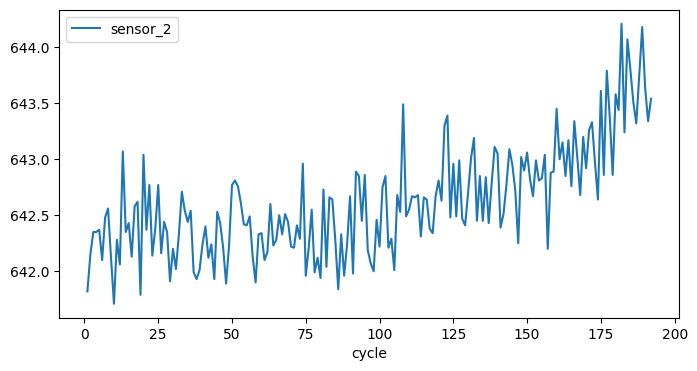

In [14]:
engine1 = data[data['engine_id'] == 1]

engine1[['cycle', 'sensor_2']].plot(x='cycle', figsize=(8,4))

<Axes: xlabel='cycle'>

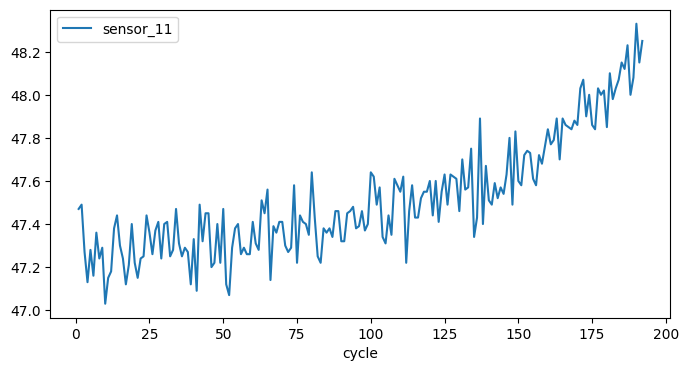

In [15]:
engine1[['cycle', 'sensor_11']].plot(x='cycle', figsize=(8,4))

In [16]:
# Get max cycle per engine
max_cycle = data.groupby('engine_id')['cycle'].max()

# Map max cycle back to dataframe
data['max_cycle'] = data['engine_id'].map(max_cycle)

# Compute RUL
data['RUL'] = data['max_cycle'] - data['cycle']

data.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [17]:
data[['cycle', 'RUL']].head()

,cycle,RUL
0,1,191
1,2,190
2,3,189
3,4,188
4,5,187


In [18]:
data['RUL'].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [19]:
RUL_cap = 125
data['RUL_clipped'] = data['RUL'].clip(upper=RUL_cap)

data[['RUL', 'RUL_clipped']].head(10)

,RUL,RUL_clipped
0,191,125
1,190,125
2,189,125
3,188,125
4,187,125
5,186,125
6,185,125
7,184,125
8,183,125
9,182,125


In [20]:
data.std().sort_values().head(10)

sensor_10       0.000000e+00
sensor_18       0.000000e+00
sensor_1        0.000000e+00
op_setting_3    0.000000e+00
sensor_19       0.000000e+00
sensor_16       1.387812e-17
sensor_5        1.776400e-15
op_setting_2    2.930621e-04
sensor_6        1.388985e-03
op_setting_1    2.187313e-03
dtype: float64

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
cols_to_drop = [
    'op_setting_3',
    'sensor_18',
    'sensor_19',
    'sensor_16',
    'sensor_10',
    'sensor_5',
    'sensor_1'
]

data = data.drop(columns=cols_to_drop)

data.shape

(20631, 22)

In [23]:
# Get unique engine IDs
engine_ids = data['engine_id'].unique()

# 80% for training, 20% for testing
train_size = int(len(engine_ids) * 0.8)

train_engines = engine_ids[:train_size]
test_engines = engine_ids[train_size:]

train_data = data[data['engine_id'].isin(train_engines)]
test_data = data[data['engine_id'].isin(test_engines)]

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (16138, 22)
Test shape: (4493, 22)


In [24]:
from sklearn.preprocessing import MinMaxScaler

# Define feature columns (remove ID and target columns)
feature_cols = train_data.columns.drop(['engine_id', 'cycle', 'max_cycle', 'RUL', 'RUL_clipped'])

scaler = MinMaxScaler()

train_data = data[data['engine_id'].isin(train_engines)].copy()
test_data = data[data['engine_id'].isin(test_engines)].copy()
train_data.head()

,engine_id,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191,125
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190,125
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189,125
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188,125
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187,125


In [25]:
# --- Split with copy (fixes warning) ---
train_data = data[data['engine_id'].isin(train_engines)].copy()
test_data = data[data['engine_id'].isin(test_engines)].copy()

# --- Define feature columns ---
feature_cols = train_data.columns.drop(['engine_id', 'cycle', 'max_cycle', 'RUL', 'RUL_clipped'])

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# --- Fit only on training ---
train_data.loc[:, feature_cols] = scaler.fit_transform(train_data[feature_cols])

# --- Transform test ---
test_data.loc[:, feature_cols] = scaler.transform(test_data[feature_cols])

train_data.head()

C:\Users\jeffi\AppData\Local\Temp\ipykernel_6120\1774610255.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.36363636 0.36363636 0.18181818 ... 0.81818182 0.81818182 0.81818182]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[:, feature_cols] = scaler.fit_transform(train_data[feature_cols])
C:\Users\jeffi\AppData\Local\Temp\ipykernel_6120\1774610255.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.27272727 0.36363636 0.54545455 ... 0.90909091 0.63636364 0.72727273]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_data.loc[:, feature_cols] = scaler.transform(test_data[feature_cols])


,engine_id,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,RUL,RUL_clipped
0,1,1,0.456647,0.166667,0.183735,0.425154,0.309757,1.0,0.726248,0.242424,...,0.633262,0.205882,0.199608,0.363986,0.363636,0.708661,0.725482,192,191,125
1,1,2,0.606936,0.250000,0.283133,0.473456,0.352633,1.0,0.628019,0.212121,...,0.765458,0.279412,0.162813,0.411312,0.363636,0.661417,0.732001,192,190,125
2,1,3,0.248555,0.750000,0.343373,0.386193,0.370527,1.0,0.710145,0.272727,...,0.795309,0.220588,0.171793,0.357445,0.181818,0.622047,0.619473,192,189,125
3,1,4,0.537572,0.500000,0.343373,0.267715,0.331195,1.0,0.740741,0.318182,...,0.889126,0.294118,0.174889,0.166603,0.363636,0.566929,0.661565,192,188,125
4,1,5,0.387283,0.333333,0.349398,0.269082,0.404625,1.0,0.668277,0.242424,...,0.746269,0.235294,0.174734,0.402078,0.454545,0.582677,0.704790,192,187,125


In [26]:
import numpy as np

def create_sequences(df, feature_cols, seq_length=30):
    X = []
    y = []

    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id]
        
        features = engine_data[feature_cols].values
        target = engine_data['RUL_clipped'].values
        
        for i in range(len(engine_data) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(target[i+seq_length-1])  # RUL at last timestep
            
    return np.array(X), np.array(y)

In [27]:
seq_length = 30

X_train, y_train = create_sequences(train_data, feature_cols, seq_length)
X_test, y_test = create_sequences(test_data, feature_cols, seq_length)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13738, 30, 17)
y_train shape: (13738,)
X_test shape: (3893, 30, 17)
y_test shape: (3893,)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(30, 17), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                20992     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 23105 (90.25 KB)
Trainable params: 23105 (90.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10


215/215 [==============================] - 16s 38ms/step - loss: 3523.1472 - mae: 49.6266 - val_loss: 1757.4159 - val_mae: 37.8237
Epoch 2/10
215/215 [==============================] - 6s 27ms/step - loss: 1740.6863 - mae: 36.8935 - val_loss: 1749.0817 - val_mae: 37.6852
Epoch 3/10
215/215 [==============================] - 6s 27ms/step - loss: 1721.9319 - mae: 36.7757 - val_loss: 1695.5756 - val_mae: 37.1922
Epoch 4/10
215/215 [==============================] - 6s 29ms/step - loss: 1089.0154 - mae: 27.7622 - val_loss: 455.1417 - val_mae: 17.5429
Epoch 5/10
215/215 [==============================] - 6s 27ms/step - loss: 338.7831 - mae: 14.2001 - val_loss: 329.8984 - val_mae: 14.6907
Epoch 6/10
215/215 [==============================] - 6s 27ms/step - loss: 266.8892 - mae: 12.5020 - val_loss: 226.1272 - val_mae: 12.0705
Epoch 7/10
215/215 [==============================] - 6s 28ms/step - loss: 255.7606 - mae: 12.1863 - val_loss: 213.1354 - val_mae: 11.6591
Epoch 8/10
215/21

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
215/215 [==============================] - 6s 27ms/step - loss: 229.2451 - mae: 11.4015 - val_loss: 183.6186 - val_mae: 10.0542
Epoch 2/50
215/215 [==============================] - 7s 30ms/step - loss: 223.2837 - mae: 11.2569 - val_loss: 311.8914 - val_mae: 13.3440
Epoch 3/50
215/215 [==============================] - 6s 27ms/step - loss: 222.5236 - mae: 11.1539 - val_loss: 242.1494 - val_mae: 11.9395
Epoch 4/50
215/215 [==============================] - 6s 27ms/step - loss: 220.1964 - mae: 11.0980 - val_loss: 176.2004 - val_mae: 10.2834
Epoch 5/50
215/215 [==============================] - 6s 27ms/step - loss: 216.0948 - mae: 11.0177 - val_loss: 196.8814 - val_mae: 10.0153
Epoch 6/50
215/215 [==============================] - 6s 28ms/step - loss: 215.8615 - mae: 10.9603 - val_loss: 170.4984 - val_mae: 9.8199
Epoch 7/50
215/215 [==============================] - 6s 27ms/step - loss: 216.3576 - mae: 10.9810 - val_loss: 222.4743 - val_mae: 11.2619
Epoch 8/50
215/215 [========

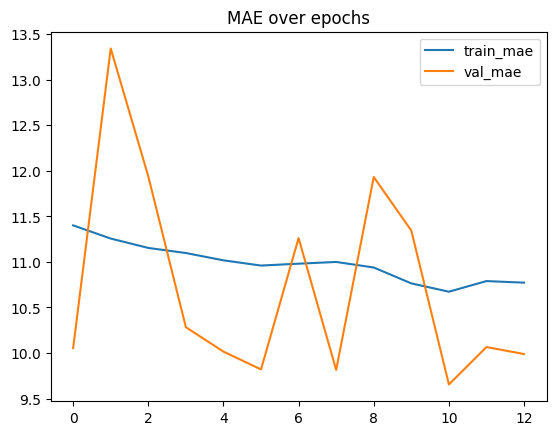

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.legend(['train_mae', 'val_mae'])
plt.title('MAE over epochs')
plt.show()

In [34]:
y_pred = model.predict(X_test)

122/122 [==============================] - 2s 9ms/step


In [35]:
y_pred = y_pred.flatten()

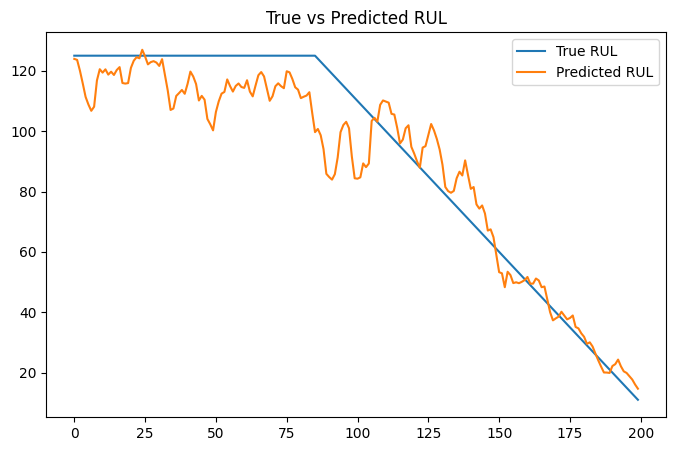

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(y_test[:200], label='True RUL')
plt.plot(y_pred[:200], label='Predicted RUL')
plt.legend()
plt.title("True vs Predicted RUL")
plt.show()

In [38]:
max_rul = 125

y_pred = y_pred.flatten()

health_index = y_pred / max_rul
risk_score = 1 - health_index

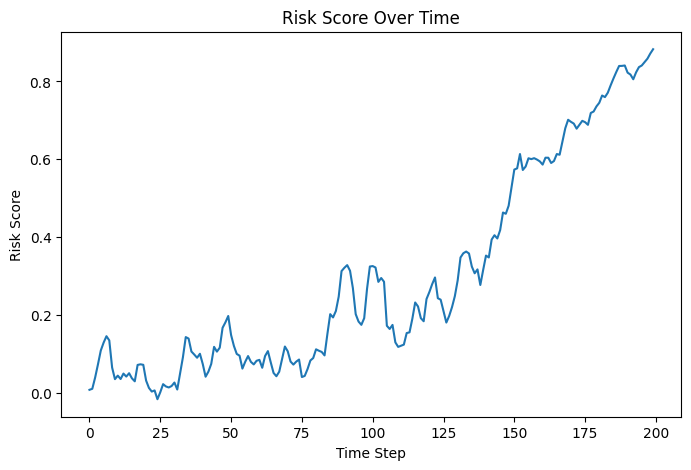

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(risk_score[:200])
plt.title("Risk Score Over Time")
plt.xlabel("Time Step")
plt.ylabel("Risk Score")
plt.show()

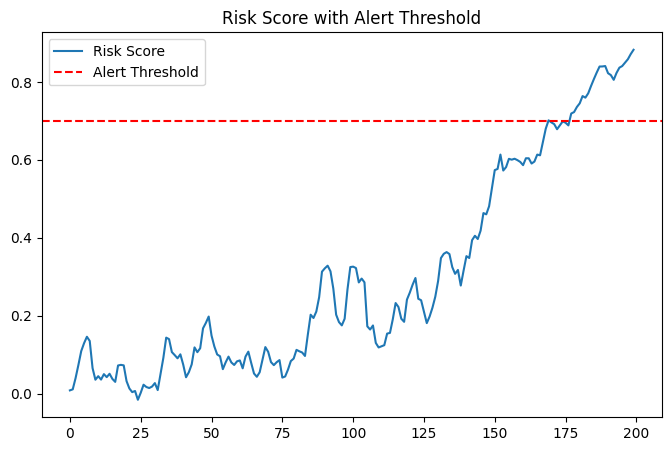

In [40]:
threshold = 0.7
alerts = risk_score > threshold

plt.figure(figsize=(8,5))
plt.plot(risk_score[:200], label="Risk Score")
plt.axhline(y=threshold, color='r', linestyle='--', label="Alert Threshold")
plt.legend()
plt.title("Risk Score with Alert Threshold")
plt.show()

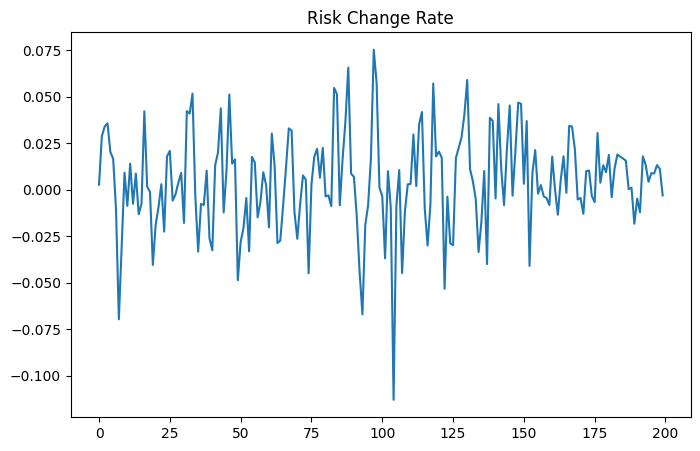

In [41]:
import numpy as np

risk_derivative = np.diff(risk_score)

plt.figure(figsize=(8,5))
plt.plot(risk_derivative[:200])
plt.title("Risk Change Rate")
plt.show()

In [62]:
# Level crossing (length N-1)
level_cross = (risk_score[1:] > 0.7) & (risk_score[:-1] <= 0.7)

# Sudden spike crossing (length N-2 originally, so pad one False at start)
sudden_cross_raw = (risk_derivative[1:] > 0.05) & (risk_derivative[:-1] <= 0.05)

# Add one False in front to align sizes
import numpy as np
sudden_cross = np.insert(sudden_cross_raw, 0, False)

# Now combine
combined_cross = level_cross | sudden_cross

In [63]:
print("Level alerts:", level_alert.sum())
print("Sudden alerts:", sudden_alert.sum())
print("Combined alerts:", combined_alert.sum())

Level alerts: 690
Sudden alerts: 108
Combined alerts: 797


In [64]:
print("Level crossing alerts:", level_cross.sum())
print("Sudden crossing alerts:", sudden_cross.sum())
print("Combined crossing alerts:", combined_cross.sum())

Level crossing alerts: 28
Sudden crossing alerts: 89
Combined crossing alerts: 117


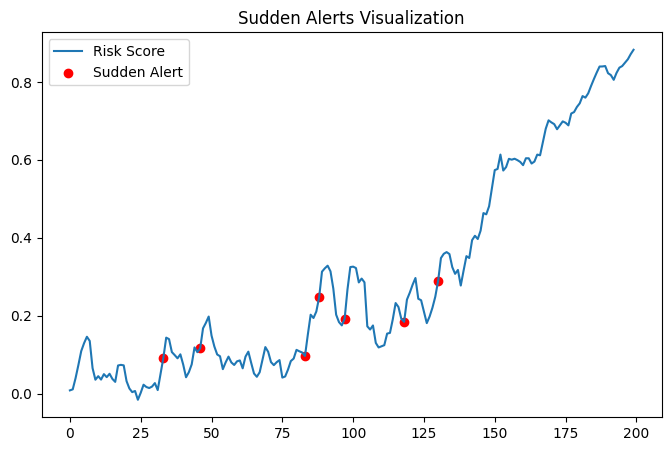

In [65]:
plt.figure(figsize=(8,5))
plt.plot(risk_score[:200], label="Risk Score")

indices = np.where(sudden_cross[:200])[0]
plt.scatter(indices, risk_score[indices], color='red', label="Sudden Alert")

plt.legend()
plt.title("Sudden Alerts Visualization")
plt.show()

In [66]:
from scipy.ndimage import uniform_filter1d

risk_smooth = uniform_filter1d(risk_score, size=5)
risk_derivative_smooth = np.diff(risk_smooth)

In [67]:
warning_zone = (risk_score > 0.6) & (risk_score <= 0.7)
critical_zone = risk_score > 0.7

In [69]:
unique_engine_ids = test_data['engine_id'].unique()

In [71]:
sequence_length = 30

engine_ids_test = []

for engine in test_data['engine_id'].unique():
    
    engine_data = test_data[test_data['engine_id'] == engine]
    
    for i in range(len(engine_data) - sequence_length):
        engine_ids_test.append(engine)

engine_ids_test = np.array(engine_ids_test)

In [80]:
engine_results = []

for engine in np.unique(engine_ids_test):

    engine_mask = engine_ids_test == engine
    engine_risk = risk_score[engine_mask]

    engine_risk_smooth = uniform_filter1d(engine_risk, size=5)

    level_cross_engine = (engine_risk_smooth[1:] > 0.7) & \
                         (engine_risk_smooth[:-1] <= 0.7)

    if level_cross_engine.any():
        first_idx = np.where(level_cross_engine)[0][0]
        real_cycle = first_idx + sequence_length
    else:
        real_cycle = None

    engine_results.append((engine, real_cycle))

print(engine_results[:10])

[(81, 205), (82, 176), (83, 251), (84, 226), (85, 159), (86, 238), (87, 149), (88, 176), (89, 182), (90, 130)]


In [81]:
failure_cycles = test_data.groupby('engine_id')['cycle'].max()

evaluation = []

for engine, critical_time in engine_results:
    if critical_time is not None:
        failure_time = failure_cycles[engine]
        lead_time = failure_time - critical_time
        evaluation.append((engine, critical_time, failure_time, lead_time))

print(evaluation[:10])

[(81, 205, 240, 35), (82, 176, 214, 38), (83, 251, 293, 42), (84, 226, 267, 41), (85, 159, 188, 29), (86, 238, 278, 40), (87, 149, 178, 29), (88, 176, 213, 37), (89, 182, 217, 35), (90, 130, 154, 24)]


In [82]:
lead_times = [item[3] for item in evaluation]

print("Average lead time:", np.mean(lead_times))
print("Minimum lead time:", np.min(lead_times))
print("Maximum lead time:", np.max(lead_times))
print("Std deviation:", np.std(lead_times))

Average lead time: 36.3
Minimum lead time: 24
Maximum lead time: 52
Std deviation: 7.142128534267638


In [84]:
model.save("nasa_lstm_rul_model.keras")

In [85]:
import os
print(os.getcwd())

C:\Users\jeffi
